# Chapter 25: Forecasting Your Own Life
Estimate duration from comparable completed projects, then examine selection and
decision risk. Synthetic data deliberately expose overrun tails; they are not
Flyvbjerg's project database or personal advice.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
rng=begin(25); ratios=rng.lognormal(.25,.45,1000); planned=12.; durations=planned*ratios

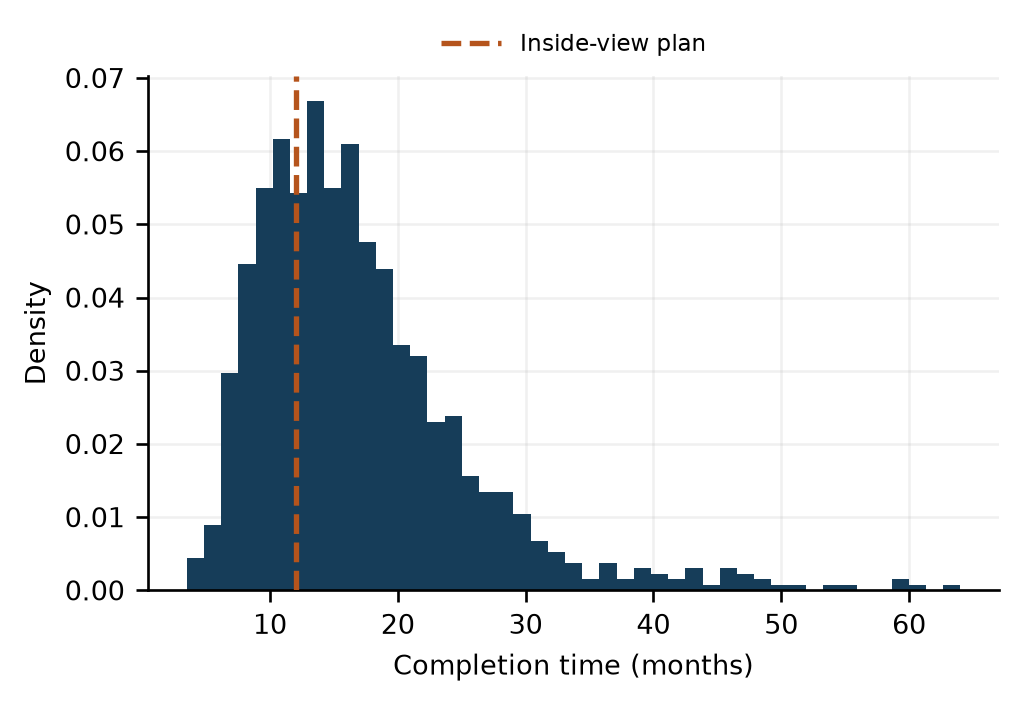

In [2]:
plt.figure(); plt.hist(durations,bins=45,density=True); plt.axvline(planned,ls='--',color='#b5541c',lw=1.6,zorder=3,label='Inside-view plan'); plt.xlabel('Completion time (months)'); plt.ylabel('Density'); plt.legend()
save(25,1,'Start with outcomes of comparable projects','Synthetic durations for projects initially planned at twelve months. The distribution is right-skewed by construction.','## Section Four: Reference Class Forecasting')

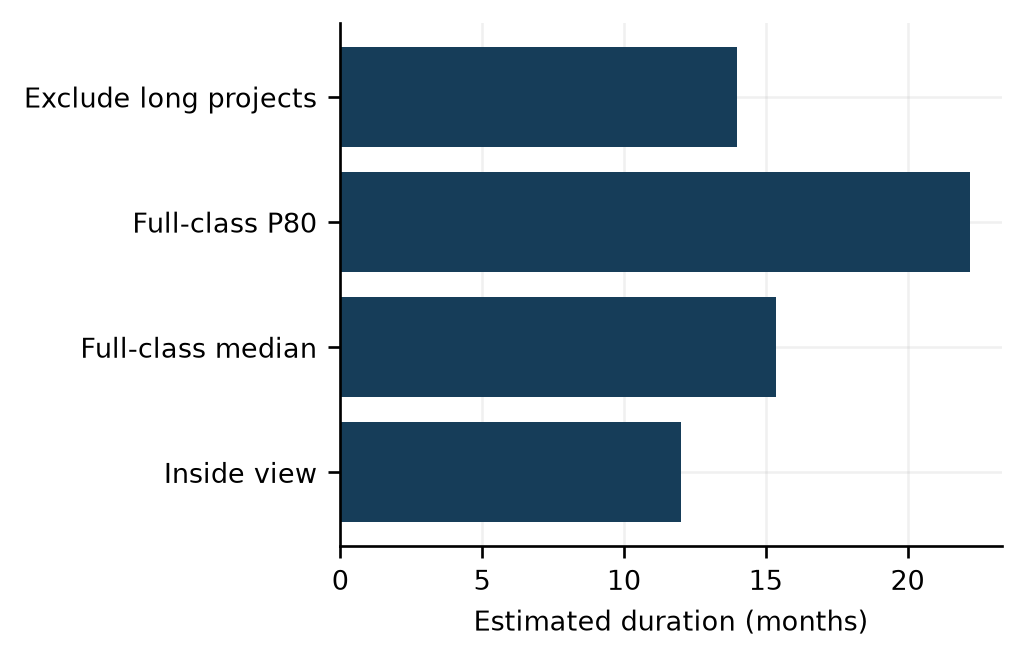

In [3]:
estimates=[planned,np.median(durations),np.quantile(durations,.8),np.median(durations[durations<24])]
plt.figure(); plt.barh(['Inside view','Full-class median','Full-class P80','Exclude long projects'],estimates); plt.xlabel('Estimated duration (months)')
save(25,2,'The class you select changes the forecast','Synthetic reference-class estimates. Excluding long projects makes the forecast optimistic; dropping abandoned or unfinished projects can introduce related bias.','## Section Five: The Hardest Reference Class')

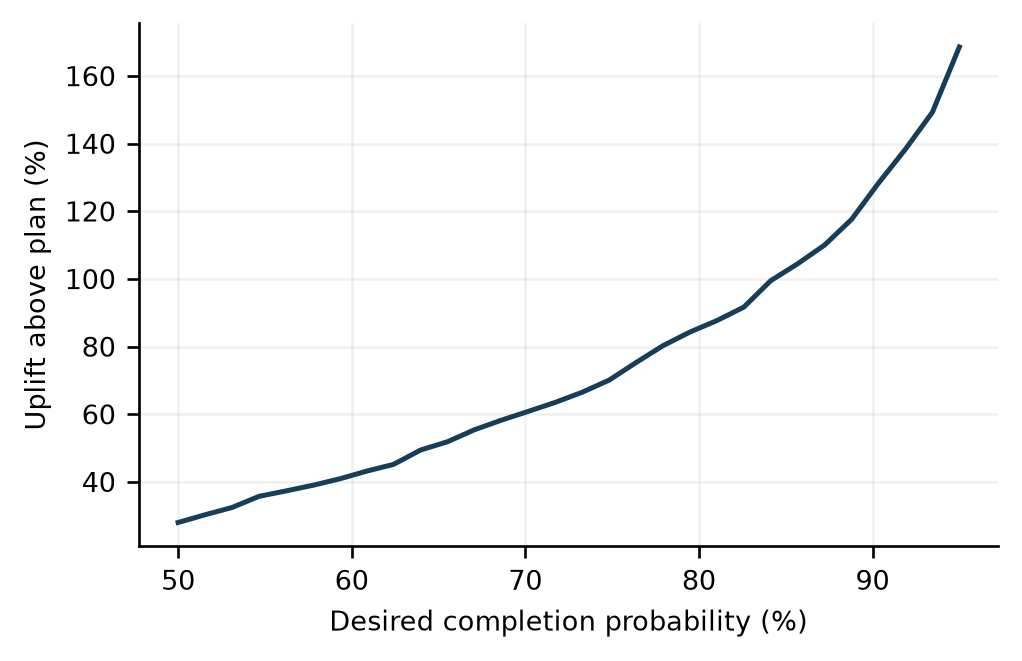

In [4]:
prob=np.linspace(.5,.95,30); uplift=(np.quantile(durations,prob)/planned-1)*100
plt.figure(); plt.plot(prob*100,uplift); plt.xlabel('Desired completion probability (%)'); plt.ylabel('Uplift above plan (%)')
save(25,3,'A commitment needs a risk level','Empirical quantiles of the synthetic duration class. Higher completion probabilities require larger contingency; the appropriate percentile depends on costs.','## Section Seven: The Full Methodology')
assert np.all(np.diff(uplift)>=0)

## Limits and exercise
Change the reference class by size, technology or execution environment before
looking at the preferred answer. The median minimizes absolute error, not every
decision loss. Unfinished projects require censoring/failure treatment rather than
simply removing them from the class.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below connect the controlled figures to a complete applied input/output workflow.

# Chapter 25 workshop: from lesson to decision

## Explain the mechanism

The outside view asks what actually happened to comparable efforts before accepting the internal plan. A forecast percentile is a decision choice: median accuracy and a high-confidence commitment are different objectives.

## Work through the arithmetic

Completed duration ratios [1,1.25,1.5,2] have median 1.375 under midpoint interpolation. A twelve-month plan multiplied by 1.375 gives 16.5 months. Quantile interpolation conventions matter in small samples and should be stated. An ongoing case at eighteen months is known only to exceed eighteen, not to finish then.

Treat this hand calculation as a mechanism check. Compare its units and assumptions with the business target before using the executable adapter below.

## Adapt the lesson to reader data

Replace generated durations with a documented class and preserve incomplete rows. The original lesson discusses censoring but does not model it; if using the applied Kaplan–Meier route, report its independent-censoring assumption and do not equate that extension with the original empirical-only chart.

Keep the controlled example as a reproducible teaching case. Work in a copy when replacing its data; retain raw input, a cleaned table and an explanation of exclusions. Real data need a named source, extraction date, usable-as-of date and units. If an actual is revised later, preserve the vintage available when the forecast would have been issued. Never silently label synthetic generator output as an external dataset.

For this chapter, settle these questions before fitting: What outcome and decision percentile matter? Which projects were comparable before their outcomes were known? Are unfinished cases censored or failed? Do plans and actuals share units?

## Interpret the actual lesson outputs

The synthetic distribution deliberately contains overruns. The optimistic selected class drops long projects, illustrating outcome-conditioned selection. The percentile curve is empirical, not an estimate from Flyvbjerg’s proprietary database or personal-life advice.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `duration_ratio,at_risk,completed,survival`.
- `summary.json`: inspect `quantiles`.

Kaplan–Meier estimates the ratio survival curve under independent right-censoring. P50/P80/P90 are the first steps crossing their cumulative probabilities, not interpolated empirical quantiles. Unsupported upper quantiles remain null. Abandonment needs a separate outcome interpretation.

The [fixture](../data/examples/ch25.csv) and [config](../configs/ch25.json) match the current interface. Run the `apply` command in the [skill entrypoint](../../forecasting-skills/forecasting-ch25-reference-classes/SKILL.md), using a new empty output folder. Any broader methodology in this workshop requires separately recorded evidence or an explicit extension; successful command execution does not imply those steps happened.

## Decide what the evidence supports

Completion-only data can underestimate durations. Independent censoring is an assumption, not guaranteed by a completed flag. Abandoned projects are not simply completed at their stop date. Small classes and changing execution conditions make high quantiles unstable.

If no comparable class exists, broaden it transparently and show sensitivity rather than asserting precision. If a survival curve never reaches the requested quantile, report that quantile not estimable. Without censoring metadata, show limitations of completed-case estimates.

The applied deliverable must make these items inspectable: Return class definition/inclusions, completion and censoring counts, empirical or survival quantiles, uplift factors, chosen commitment and its decision rationale, plus unidentifiable tail risks.

## Three exercises with worked solutions

### Exercise 1

Median overrun ratio 1.4, new plan 10 months: outside-view median?

**Worked solution.** 14 months, conditional on class comparability.

### Exercise 2

An unfinished project has elapsed 20 months. Should actual=20 be treated as a completed duration?

**Worked solution.** No. It is right-censored at 20 if the observation mechanism supports that interpretation.

### Exercise 3

Estimated completion probability reaches only .7 by last follow-up. Can P90 be reported numerically?

**Worked solution.** Not from that observed survival curve without additional tail assumptions; mark it unestimable.

## Business-reader application

Use this request with the skill:

> Apply chapter 25 to projects.csv, retain censored cases, defend the reference class and translate supported quantiles into a commitment aligned with delay costs.

Read the returned result as a decision record. Check that the forecast answers your unit and horizon, that its comparison uses information available at the time, and that any recommendation follows from the stated loss or business objective. Ask which missing measurement would most change the conclusion.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

## Configure and run the applied case

The input file and JSON below are the only entry-point changes needed to try another
case with the same schema. Keep the original examples for comparison. Supply source
and units in the configuration; resolve missing periods rather than silently filling
unknown observations with zeros. These calculations call the same tested functions
as the `run.py apply` command. A failed validation is a reason to inspect the data,
not to replace it with invented observations.

The default input here is a **seeded synthetic schema example**, separate from any
observed-data application below. Read the summary before interpreting its results.

In [5]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json
import pandas as pd
import json, os
INPUT_PATH = project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists()) / 'companion/data/examples/ch25.csv'
CONFIG_PATH = project_path.parents[2] / 'configs/ch25.json'
# Input paths are explicit and may be replaced with reader-supplied files.
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(25, workshop_input, workshop_config)
print(json.dumps(clean_json(workshop_summary), indent=2))
print(workshop_table.head(12).to_string(index=False))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', CONFIG_PATH.parents[1])) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch25-workshop-results.csv', index=False)
(workshop_output/'ch25-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

{
  "quantiles": {
    "0.5": 1.4079476180834145,
    "0.8": null,
    "0.9": null
  },
  "interpretation": "Kaplan\u2013Meier ratios treat incomplete actual durations as right-censored elapsed time. This requires noninformative censoring; abandonment as failure may violate it. Unidentified upper quantiles remain null, never invented."
}
 duration_ratio  at_risk  completed  survival
       0.444639       60          1  0.983333
       0.554330       59          1  0.966667
       0.571632       58          1  0.950000
       0.586248       57          1  0.933333
       0.631293       56          1  0.916667
       0.636456       55          1  0.900000
       0.637707       54          1  0.883333
       0.652436       53          1  0.866667
       0.699606       52          1  0.850000
       0.812864       51          1  0.833333
       0.814529       50          1  0.816667
       0.852950       49          1  0.800000


340

## Real-data boundary

The bundled case is controlled, not a reconstruction of historical records. No
verified, appropriately licensed domain dataset is supplied for this particular
workflow. Use the input contract to supply your own observations and evidence.
Do not substitute an unrelated public dataset simply to call the example real.
The wider companion includes observed time-series applications in chapters
3–6, 12, 15–16 and 24; their data do not establish this chapter’s domain assumptions.

## Read the result as a decision record

Start with the summary’s **interpretation**, then examine its numerical evidence.
Distinguish what was fitted, what was supplied, and what remains unidentified.
The results table is the calculation; it is not permission to act. Explain which
assumption would most change the answer and what new evidence would test it.
For a live forecast, set an outcome date and keep the original result for scoring.

The exercises and worked solutions above test interpretation, calculation, and
adaptation. Re-run a changed assumption and compare the actual output; do not
reuse numbers from the book when your input or horizon changes.